# **단백질 언어 모델(직관 편): 알려진 단백질 세계의 구문과 의미 모델링에 대한 첫걸음**

작성: Dhuvi Karthikeyan, Aaron Menezes, Elisa Gómez de Lope, Rakshit Singh

## Colab에서 실행하기

이 노트북은 Google Colab에서 실행하는 것을 권장합니다. 아래 Colab 배지를 클릭하면 바로 열립니다. (Kaggle에서도 열 수 있습니다.)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/isg-yhlee93/lecture/blob/main/Modeling%20Proteins/5_ProteinLM_Tutorial0.ipynb)
[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/isg-yhlee93/lecture/blob/main/Modeling%20Proteins/5_ProteinLM_Tutorial0.ipynb)


BERT, T5, GPT 같은 대형 언어 모델(LLM)이 감성 분석, 요약, 질의응답, 분류 과제에서 최첨단 성능을 보인 데 영감을 받아, 단백질 언어 모델(pLM)도 다양한 단백질 특화 과제에서 비슷한 폭넓은 성공을 거두었습니다. 이러한 과제에는 접촉 예측(contact prediction), 돌연변이 적합도 예측, 결합 부위 예측, 물성 예측 등이 있습니다! 이 튜토리얼에서는 단백질 언어 모델 성공의 근간이 되는 기본 직관을, 내부에서 실제로 무슨 일이 일어나는지와 그로 인한 장단점을 중심으로 살펴봅니다. 다른 도메인의 언어 모델을 더 알고 싶다면, 화학 도메인에 학습된 DeepChem의 ChemBERTa를 [여기](https://deepchem.io/tutorials/transfer-learning-with-chemberta-transformers/)에서 확인하세요.

#### 목차:
1. [소개](#introduction)
2. [언어 모델이란 무엇인가?](#what-is)
3. [언어를 학습하는 방법](#methods)
4. [단백질 언어 모델(pLM)은 어떻게 작동하는가?](#how-to)
5. [MSA 인식 vs 비MSA 인식 단백질 언어 모델](#msa)
6. [헤모글로빈 𝛽의 진화적 통계와 ProtBERT가 학습한 표현](#hemoglobin)
7. [맺음말](#conclusion)


## **1. 소개(Introduction)** <a name="introduction"></a>


이 DeepChem 튜토리얼은 단백질 언어 모델에 대한 입문 안내서로 설계되었습니다. 단백질 언어 모델은 자연어 분야의 기법에서 영감을 받은, 단백질 서열 정보를 처리하는 강력하고 다재다능한 방법입니다. 지난 10년간 자연어 처리는 학습된 표현(learned representation)을 사용해 텍스트 데이터의 의미를 담아내는 강력함을 보여주었습니다. word2vec [[1]](https://arxiv.org/abs/1301.3781), GloVe [[2]](https://aclanthology.org/D14-1162/) 같은 모델은, 크고 레이블 없는 말뭉치에서의 자기지도 사전학습이 언어의 유사성과 유추를 유지하는 견고한 특징 임베딩을 효과적으로 만들어낸다는 것을 증명했습니다. 다만 이 모델들은 문맥 비의존(context-free) 임베딩이라는 점에서 활용이 제한적이었습니다. BERT [[3]](https://aclanthology.org/N19-1423/)를 시작으로 한 문맥 인식(context-aware) 모델의 등장은, 언어 도메인을 넘어 적용 가능한 수많은 시퀀스 모델로 이어졌습니다. 생물학에서도, 단백질 언어 모델의 자기지도 사전학습은 문맥 인식 아미노산 임베딩을 도출하여 단백질의 구조 [[4]](https://www.biorxiv.org/content/10.1101/2020.12.15.422761v1)와 기능 [[5]](https://www.biorxiv.org/content/early/2023/08/24/2023.08.23.554486.full.pdf) 정보를 포착하도록 미세조정될 수 있어, 다양한 과제에서 최첨단 성능을 달성했습니다.

이 튜토리얼은 단백질 언어 모델을 다루고 그 입출력·강점·실패 양상을 이해하는 데 필요한 개념과 직관의 개요를 제공하는 것을 목표로 합니다. 구조의 상세한 분석은 건너뛰지만, 커뮤니티가 풀 리퀘스트(pull request) 형태로 내용을 보태주시길 환영합니다.

**면책 조항**: 간결함을 위해 다층 퍼셉트론(MLP), 신경망, 경사하강법(gradient descent) 학습에 어느 정도 익숙하다고 가정합니다. 또한 이산 분포 대 연속 분포, 가능도(likelihood), 조건부 분포 같은 확률 이론에 어느 정도 익숙하다고 가정합니다. 명확하지 않은 주제와 개념은 필요한 곳마다 외부 자료 링크를 제공합니다. 단백질 언어 모델이 폭넓은 과제에서 큰 성공을 거둔 이유를 큰 그림에서 함께 살펴봅시다.


## **2. 언어 모델이란 무엇인가?**<a name="what-is"></a>


내부적으로 모든 언어 모델은 토큰(token), 즉 이산적인 하위 시퀀스에 대한 확률 분포에 지나지 않습니다. 자연어에서 매우 직관적인 토큰 집합은 언어의 단어들, 혹은 문자들입니다. 둘 다 각각의 장단점이 있습니다. 여기서는 단순함을 위해 단어를 토큰으로 다루겠습니다(단백질에서는 달라집니다). 학습된 분포가 이산 단위(단어)에 대한 것이므로, 이 분포는 연속 분포가 아니라 [범주형 분포(categorical distribution)](https://en.wikipedia.org/wiki/Categorical_distribution)입니다. 더 구체적으로, 여러분이 살면서 여러 번 접했을 흔한 언어 모델인 텍스트 자동완성을 예로 들어봅시다. 텍스트 자동완성은 여러분이 앞서 쓴 단어들을 받아 어휘 내 모든 단어에 대한 [조건부 확률](http://www.stat.yale.edu/Courses/1997-98/101/condprob.htm)을 계산하고, 맥락에 따라 가장 확률이 높은 단어를 반환하는 조건부 언어 모델입니다. 언어 모델의 형태와 기능에 대한 직관적이고 세밀한 설명을 원한다면, 3Blue1Brown의 [해설](https://www.3blue1brown.com/lessons/gpt)이 구조의 기초, 정보의 흐름, 특정 LLM(GPT) 학습 과정을 잘 풀어주는 훌륭한 자료입니다. 이 절에서는 언어 모델의 구조는 블랙박스로 두고, 단백질 도메인에서의 활용 동기를 더 잘 설명하기 위해 언어 모델이 시퀀스로부터 어떻게 학습하는지에 집중합니다.

언어 모델이 내부에서 하는 일을 시각화하는 간단한 방법은, 언어 모델을 $D \times D$ 크기의 거대한 정사각 [전이 확률(transition probability)](https://en.wikipedia.org/wiki/Stochastic_matrix) 행렬을 갱신하고 색인하는 것으로 생각하는 것입니다. 여기서 $D$는 모델의 어휘 크기(vocabulary size)입니다. 어휘 크기란 범주형 분포의 상태 공간을 이루는 고유한 단어 또는 하위 단어의 수를 말합니다. 그래서 ['a', 'boy', 'cute', 'is', 'student', 'the', 'walking'] 단어만 아는 모델은 어휘 크기가 7입니다. 무작위로 초기화된 학습되지 않은 모델에서 시작하면, [균등(uniform)](https://www.investopedia.com/terms/u/uniform-distribution.asp) 초기화를 사용해 다음과 같은 전이 행렬을 얻게 됩니다(여기서는 시퀀스의 끝을 나타내는 특수 단어 EOS를 도입합니다):

|         | a    | boy  | cute | is   |student| the     | walking | EOS |
|---------|------|------|------|------|-------|---------|---------|-----|
| a       | 0.125| 0.125| 0.125| 0.125| 0.125 | 0.125   | 0.125   |0.125|
| boy     | 0.125| 0.125| 0.125| 0.125| 0.125 | 0.125   | 0.125   |0.125|
| cute    | 0.125| 0.125| 0.125| 0.125| 0.125 | 0.125   | 0.125   |0.125|
| is      | 0.125| 0.125| 0.125| 0.125| 0.125 | 0.125   | 0.125   |0.125|
| student | 0.125| 0.125| 0.125| 0.125| 0.125 | 0.125   | 0.125   |0.125|
| the     | 0.125| 0.125| 0.125| 0.125| 0.125 | 0.125   | 0.125   |0.125|
| walking | 0.125| 0.125| 0.125| 0.125| 0.125 | 0.125   | 0.125   |0.125|


하지만 전이 확률 일부를 보면, 이 모델이 별로 좋지 않다는 것을 바로 알 수 있습니다. 예를 들어 'a' 다음에 'a'가 올 확률은 0에 가까워야 합니다. 'a' 다음에 'the'가 오는 것도 마찬가지입니다. 현실적인 전이 확률을 얻으려면 이 모델을 학습시킬 방법이 필요하다는 것이 분명합니다.


## **3. 언어를 학습하는 방법**<a name="methods"></a>


#### 3.1 인과적 모델링(Causal Modeling)


최초의 언어 모델들은 [인과적 언어 모델링(causal language modeling)](https://huggingface.co/docs/transformers/en/tasks/language_modeling) 원리로 학습되었습니다. 이는 각 학습 단계에서 모델이 다음 단어를 예측하도록 하는 방식입니다.

$$\text{The quick brown fox jumped over the lazy -----.}$$
$$ P(x_t|x_{<t}) = ? $$

이 학습 프로토콜을 충분히 반복하면, 모델은 다음과 같은 훨씬 더 그럴듯한 단어 분포를 학습합니다:

|         | a    | boy  | cute | is   |student |  the  | walking| EOS  |
|---------|------|------|------|------|---------|-------|--------|-----|
| a       | 0.0  | 0.5  | 0.1  | 0.05 | 0.25    | 0.05  |0.05    | 0.0 |
| boy     | 0.15 | 0.0  | 0.1  | 0.4  | 0.05    | 0.15  |.05     | 0.1 |
| cute    | 0.05 | 0.2  | 0.0  | 0.1  | 0.25    | 0.1   |0.0     | 0.3 |
| is      | 0.2  | 0.0  | 0.3  | 0.0  | 0.0     | 0.2   |0.3     | 0.0 |
| student | 0.15 | 0.05 | 0.1  | 0.5  | 0.0     | 0.05  |.05     | 0.1 |
| the     | 0.0  | 0.5  | .2   | 0.0  | 0.25    | 0.0   |0.05    | 0.0 |
| walking | 0.1   | .0   | .05  | .2   | .05    | 0.35 |0.0      | 0.3 |
| EOS     | 0.0  | 0.0   | 0.0 | 0.0   | 0.0    | 0.0   | 0.0    | 1.0 |

여기서 모델이 위 단어들은 보통 연속해서 두 번 반복되지 않는다는 것을 학습했음을 볼 수 있습니다. 'the' 다음에는 동사 ['is', 'walking']보다 주어 단어 ['boy', 'student']에 더 높은 확률을 부여합니다. 'the'에서 시작해 각 전이마다 가장 확률 높은 단어를 샘플링하면, 모델을 통과하는 경로로 다음 문장을 생성할 수 있습니다: 'the' -> 'boy' -> 'is' -> 'walking' -> 'EOS'. 매 시점마다 단어를 샘플링하고 앞서 샘플링한 단어에 조건을 거는 이 방식을 자기회귀 생성(auto-regressive generation)이라고 합니다.


#### 3.2 신경망의 힘


여기서 언어 모델링 과제에 점점 더 복잡한 신경망을 쓰게 만드는 핵심은, 위의 예시처럼 전이 확률 행렬을 두고 매 단계 [마르코프 체인(Markov chain)](https://en.wikipedia.org/wiki/Markov_chain)처럼 샘플링한다는 점입니다. 그런데 언어에는 바로 앞 단어에 조건을 거는 것만으로는 포착되지 않는, 더 긴 범위의 의존성이 있습니다. 그렇다면 단어 쌍이나 삼중, 혹은 그 이상 사이의 전이 확률을 매핑하는 행렬을 만들면 안 될까요? 계산 가능성 문제를 차치하더라도, 이런 모델은 가능한 모든 n-그램이 학습 중 최소 한 번은 등장해야 하므로 모델의 학습과 활용성을 크게 제한합니다. 신경망은, 어휘 내 모든 단어와 신경 표현(neural representation)을 매핑하는 느슨한 전이 행렬을 색인하기 전에, 큰 맥락을 사용해 시퀀스의 신경 표현을 생성하는 훌륭한 방법으로 떠올랐습니다. 이 때문에 언어 모델 분야에서는 신경망 마지막 층의 어휘 분포를 확률 행렬이 아니라 1차원 확률 분포로 보는 경우가 많습니다. 이를 염두에 두면, 이 언어 모델들이 단어의 앞 **그리고** 뒤 맥락을 모두 활용해 언어를 학습하는 또 다른 방법을 어떻게 수용하는지 알 수 있습니다.


#### 3.3 마스킹 언어 모델링(Masked Language Modeling)


인과적 언어 모델링에는 핵심적인 단점이 있습니다. 때로는 문장에서 한 단어를 이해하는 데 필요한 맥락이 그 단어 앞이 아니라 뒤에 온다는 점입니다. 마스킹 언어 모델링은 인과적 모델링과 비슷하지만, 관심 단어의 앞뒤 모두에서 맥락이 올 수 있다는 점을 활용합니다.

$$\text{The quick brown [MASK] jumped over the lazy dog.}$$
$$ P(x_t|x_{! t}) = ??$$

이 접근법이 강력한 BERT [[3]](https://arxiv.org/pdf/1810.04805) 언어 모델의 근간이며, 단어의 약 15%를 마스킹하는 마스킹 비율을 사용했습니다. 놀랍게도 이 접근법은 언어 외의 시퀀스에도 시도되어, 시계열 데이터, 동영상, 그리고 그렇습니다, 단백질까지 다양한 양상의 순차 데이터의 구문과 의미를 학습하는 견고한 모델임이 입증되었습니다!


## **4. 단백질 언어 모델(pLM)은 어떻게 작동하는가?**<a name="how-to"></a>


다양한 자연어 과제에서 [대형 언어 모델(LLM)](https://magazine.sebastianraschka.com/p/understanding-large-language-models)이 거둔 성공에 영감을 받아, 단백질 언어 모델은 단백질 서열의 구문과 의미를 이해하는 강력한 새 접근법으로 자리잡았습니다 [[6]](https://arxiv.org/abs/2007.06225). 이 모델들은 마스킹 언어 모델링 목표를 사용해 서열의 일부를 가리고 수십억 개의 단백질 서열에 걸쳐 어떤 아미노산이 들어갈지 추론하도록 학습하며, 구조와 기능에 결정적인 서열 내 패턴과 관계를 식별하는 법을 배웁니다. 이 단계를 사전학습(pre-training)이라 하며, 이를 통해 언어 모델은 해당 언어(여기서는 단백질) 내 구조적 의존성에 대한 일반적 이해를 갖추게 됩니다.

선택적인 두 번째 학습 단계인 [미세조정(fine-tuning)](https://medium.com/@bijit211987/the-evolution-of-language-models-pre-training-fine-tuning-and-in-context-learning-b63d4c161e49)은 사전학습된 단백질 언어 모델에 적용되어, 레이블이 달린 단백질 서열 예제로 특정 작업에 맞게 추가 학습합니다. 실제로 사전학습 가중치에서 시작하는 것이 무작위 초기화에서 시작하는 것보다 성능이 좋습니다. 모델이 표현과 그 사용법을 함께 배우는 대신, (사전학습에서 배운) 강력한 입력 표현을 어떻게 사용할지만 배우면 되기 때문입니다. 특정 단백질 패밀리나 기능 클래스의 매핑에 미세조정된 pLM은 비사전학습 모델보다 예측력을 크게 높일 수 있고, 결합 부위 예측이나 돌연변이 효과 예측 등 다양한 용도에 적용될 수 있습니다.

pLM의 가장 강력한 이점 중 하나는, 단백질 서열 내·서열 간 공진화(coevolution) 관계를 포착하는 능력입니다 [[7]](https://www.biorxiv.org/content/10.1101/2024.01.30.577970v1.full.pdf). 문장 속 단어들이 함께 등장해 일관된 의미를 전달하듯, 단백질 서열의 아미노산 잔기들도 단백질의 구조적 무결성과 기능을 유지하기 위해 함께 진화합니다. pLM은 이러한 공진화 패턴을 포착하여, 단백질의 한 부분의 변화가 다른 부분에 어떤 영향을 줄지 예측할 수 있게 합니다. 따라서 설계 관점에서 유도 진화(directed evolution) 과제는 pLM이 상당한 이점을 제공하는 영역입니다. 유도 진화 실험에서는 자연적으로 존재하는 단백질을 임의의 휴리스틱에 따라 돌연변이시킨 뒤, 원하는 기능이 개선되었는지 확인합니다. pLM은 서열 내 조건부 분포를 포착하므로, '돌연변이'시키고 싶은 단백질 부분을 마스킹하고 나머지 서열을 고려할 때 강력한 후보 아미노산 분포에서 샘플링함으로써 이 과정을 크게 간소화할 수 있습니다. 이렇게 pLM은 더 높은 적중률로 유망 후보를 식별하여 실험 부담을 크게 줄일 잠재력이 있습니다.


#### 4.1 서열과 구조의 조화

일부 단백질 언어 모델은 학습 입력에서 아미노산 서열 데이터와 함께, 단백질 내 원자의 3D 좌표 같은 구조 데이터를 결합합니다. 목표는 구조 정보를 명시적으로 통합하여, 미지 단백질 구조·기능의 표현과 궁극적 예측을 향상시키는 것입니다. 이는 상동성(homology)을 통해 단백질 간 더 잘 보존되는 구조를 암묵적으로 모델링하는 서열 전용(sequence-only) 모델과 대비됩니다.

ESM-1b [[4]](https://www.biorxiv.org/content/10.1101/2020.12.15.422761v1.full.pdf), ESM-2 [[8]](https://www.biorxiv.org/content/10.1101/2022.07.20.500902v3) 같은 모델은 3D 구조 정보를 명시적으로 통합하지 않는 서열 전용 pLM의 예입니다. 이런 서열 기반 pLM은 대규모 단백질 서열 데이터셋에서 패턴을 학습함으로써 다양한 단백질 기능 예측 과제에서 인상적인 성능을 보였습니다. 다만 구조 정보의 부재는 서열 전용 pLM의 일반화 능력을 제한할 수 있습니다. 특히 접촉 예측처럼 단백질 구조에 크게 의존하는 응용에서 그렇습니다. 또한 구조 정보의 포함은 서열 학습 데이터셋에 존재하는 분포적 편향을 극복하는 데 도움이 됩니다.

S-PLM [[9]](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10441326/), ESM-Fold [[8]](https://www.biorxiv.org/content/10.1101/2022.07.20.500902v3) 같은 구조 인식(structure-aware) pLM은 서열과 구조 정보를 모두 사용해 학습하며, 서열과 구조 정보를 모두 인코딩한 단백질 표현을 생성합니다. 이 모델들은 다중 뷰 대조 학습(multi-view contrastive learning) 같은 방법으로 서열·구조 표현을 공유 잠재 공간(shared latent space)에 정렬합니다(S-PLM). 이러한 구조 인식 능력 덕분에, 특히 단백질 구조에 크게 의존하는 응용에서 전문 구조 기반 방법이나 서열 기반 pLM에 견줄 만하거나 더 우수한 성능을 달성합니다.

흥미롭게도 최근 공개된 ESM-3 [[10]](https://www.evolutionaryscale.ai/blog/esm3-release) pLM은 서열, 구조, 기능을 함께 추론합니다. 즉 각 단백질에 대해 서열·구조·기능을 추출·토큰화하고 사전학습 중 부분적으로 마스킹합니다.

![image.png](https://www.biorxiv.org/content/biorxiv/early/2024/05/13/2023.08.06.552203/F1.large.jpg?width=800&height=600&carousel=1)

*S-PLM의 프레임워크와 다운스트림 지도학습을 위한 경량 튜닝 전략. a, S-PLM 프레임워크: 사전학습 동안 모델은 아미노산 서열과 단백질 구조에서 유도된 접촉 지도(contact map)를 동시에 입력받습니다. 사전학습 후, 프로젝터 층 이전에 AA 수준 임베딩을 생성하는 ESM-Adapter가 다운스트림 작업에 사용됩니다. ESM-Adapter 전체는 완전히 동결하거나 경량 튜닝으로 학습 가능하게 할 수 있습니다. b, ESM-Adapter 구조. c, 지도 다운스트림 작업을 위한 Adapter 튜닝. d, 지도 다운스트림 작업을 위한 LoRA 튜닝. [[9]](https://www.biorxiv.org/content/10.1101/2023.08.06.552203v3)에서 발췌.*


## **5. MSA 인식 vs 비MSA 인식 단백질 언어 모델**<a name="msa"></a>


다중 서열 정렬(Multiple Sequence Alignment, MSA)은 셋 이상의 생물학적 서열(단백질 또는 핵산)을 정렬하여, 기능적·구조적·진화적 관계를 시사할 수 있는 유사 영역을 식별하는 방법입니다. MSA는 계통 분석, 구조 예측, 기능 주석(annotation) 같은 작업에서 생물정보학의 초석입니다.

pLM의 맥락에서 MSA는 단백질 서열 표현에 진화적 맥락을 제공합니다. pLM은 MSA 인식(MSA-aware)일 수도, 비MSA 인식(non-MSA-aware)일 수도 있습니다:


#### **MSA 인식 모델:**


MSA Transformer [[11]](https://proceedings.mlr.press/v139/rao21a.html), Evoformer(AlphaFold에 사용) [[12]](https://www.nature.com/articles/s41586-021-03819-2), ESM-MSA [[11]](https://proceedings.mlr.press/v139/rao21a.html) 같은 MSA 인식 모델은, 진화 정보와 서열 간 관계를 통합해 더 풍부한 표현을 학습하기 위해 MSA를 입력으로 포함한 데이터셋으로 학습됩니다. 이들은 여러 상동 서열을 정렬해 보존 영역과 변이 영역을 포착합니다. 보존 영역은 흔히 기능적·구조적으로 중요한 부분을 나타내고, 변이 영역은 진화적 분기와 적응에 대한 통찰을 줄 수 있다는 것이 그 근거입니다.

MSA 인식 모델은 진화적 맥락 덕분에 단백질 기능과 구조에 대한 더 깊은 통찰을 제공할 수 있습니다. 다만 계산 비용이 크고 고품질 MSA가 필요한데, 모든 단백질 패밀리에 대해 그런 MSA를 구할 수 있는 것은 아닙니다.


#### **비MSA 인식 모델:**


ESMFold(ESM-2) [[8]](https://www.biorxiv.org/content/10.1101/2022.07.20.500902v3), ProtBERT [[6]](https://arxiv.org/abs/2007.06225), TAPE 같은 비MSA 인식 모델은 각 단백질 서열을 독립적으로 다루며, MSA의 진화 정보를 명시적으로 통합하지 않습니다. 이들은 개별 단백질 서열의 대규모 데이터셋으로 학습되어, 서열 데이터로부터 직접 패턴과 표현을 배웁니다.

다양한 서열에 잘 일반화되고 계산적으로 효율적이지만, 특정 작업에 결정적일 수 있는 진화적 맥락을 놓칠 수 있습니다.

<img src="https://cdn.prod.website-files.com/621e95f9ac30687a56e4297e/64a8d21628b03e0f9f71a4fc_V2_1677884143661_5f927638-5fb9-40ac-9301-8f25c3bcf649.png" alt="image.png" width="800">

"*Multiple Sequence Alignment". BioRender.*


#### **MSA 인식 모델의 이점과 도전 과제:**


- 진화적 통찰: MSA는 진화 정보를 제공하여, 단백질 기능과 구조에 흔히 결정적인 보존 잔기를 부각합니다.
- 향상된 예측: 진화적 맥락을 통합함으로써, MSA 인식 모델은 2차 구조 예측, 접촉 예측, 기능 주석 같은 작업에서 성능을 개선할 수 있습니다.
- 기능적·구조적 이해: MSA는 기능적으로 중요한 영역을 식별하고 단백질의 구조적 제약을 이해하는 데 도움을 줍니다.
- 계산 복잡도: MSA를 생성·처리하는 것은 계산 비용이 크고 시간이 많이 듭니다.
- 데이터 가용성: 고품질 MSA는 모든 단백질 패밀리, 특히 알려진 상동체가 거의 없는 경우에는 구하기 어렵습니다.
- 모델 복잡도: MSA 인식 모델은 더 복잡하며, 진화 정보를 효과적으로 활용하려면 정교한 구조가 필요합니다.


기타 고려 사항:
- 단백질의 3D 구조뿐 아니라 기능 및 기타 성질을 예측하는 데 있어 MSA 인식·비MSA 인식 모델의 성능 벤치마크는 현재 활발히 연구되는 주제입니다.
- 흥미롭게도, MSA 없는(MSA-free) 모델이 MSA 인식 모델의 입력으로 쓸 만큼 충분히 정확한 MSA를 효율적으로 생성할 수 있다는 보고도 있습니다.


#### 자, 이제 본격적으로 단백질 언어 모델의 여러 성질을 실제로 탐구해 봅시다!


## **6. 헤모글로빈 𝛽의 진화적 통계와 ProtBERT가 학습한 표현**<a name="hemoglobin"></a>


![hemoglobin.png](https://www.researchgate.net/profile/Lakna-Panawala/publication/313841668/figure/fig1/AS:463461898559488@1487509335507/Structure-of-Hemoglobin.png)

이미지 출처: *"Représentation simplifiée de l'hémoglobine et de l'hème". Wikimedia Commons에서 각색.*

헤모글로빈은 적혈구를 통해 폐에서 우리 몸 모든 세포로 산소를 운반하는 단백질입니다. 헤모글로빈은 단백질 언어 모델의 행동을 살펴보기에 좋은 단백질인데, 종(species)에 걸쳐 특정 영역은 고도로 보존되어 있고 다른 부분은 약간 가변적이기 때문입니다. 고도로 보존된 영역을 마스킹하면 아미노산 분포가 어떻게 보일까요? 고도로 다양한 영역은요? 직접 확인해 봅시다.

**가까운 포유류 간 헤모글로빈 서열 상동성** (출처: [[13]](https://www.nature.com/articles/s41598-019-50619-w)):


In [ ]:
hemoglobin_beta = {
'human':
"MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH",
'chimpanzee':
"MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTORFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH",
'camel':
"MVHLSGDEKNAVHGLWSKVKVDEVGGEALGRLLVVYPWTRRFFESFGDLSTADAVMNNPKVKAHGSKVLNSFGDGLNHLDNLKGTYAKLSELHCDKLHVDPENFRLLGNVLVVVLARHFGKEFTPDKQAAYQKVVAGVANALAHRYH",
'rabbit':
"MVHLSSEEKSAVTALWGKVNVEEVGGEALGRLLVVYPWTQRFFESFGDLSSANAVMNNPKVKAHGKKVLAAFSEGLSHLDNLKGTFAKLSELHCDKLHVDPENFRLLGNVLVIVLSHHFGKEFTPQVQAAYQKVVAGVANALAHKYH",
'pig':
"MVHLSAEEKEAVLGLWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSNADAVMGNPKVKAHGKKVLQSFSDGLKHLDNLKGTFAKLSELHCDQLHVDPENFRLLGNVIVVVLARRLGHDFNPNVQAAFQKVVAGVANALAHKYH",
'horse':
"*VQLSGEEKAAVLALWDKVNEEEVGGEALGRLLVVYPWTQRFFDSFGDLSNPGAVMGNPKVKAHGKKVLHSFGEGVHHLDNLKGTFAALSELHCDKLHVDPENFRLLGNVLVVVLARHFGKDFTPELQASYQKVVAGVANALAHKYH",
'bovine':
"M**LTAEEKAAVTAFWGKVKVDEVGGEALGRLLVVYPWTQRFFESFGDLSTADAVMNNPKVKAHGKKVLDSFSNGMKHLDDLKGTFAALSELHCDKLHVDPENFKLLGNVLVVVLARNFGKEFTPVLQADFQKVVAGVANALAHRYH",
'sheep':
"M**LTAEEKAAVTGFWGKVKVDEVGAEALGRLLVVYPWTQRFFEHFGDLSNADAVMNNPKVKAHGKKVLDSFSNGMKHLDDLKGTFAQLSELHCDKLHVDPENFRLLGNVLVVVLARHHGNEFTPVLQADFQKVVAGVANALAHKYH"
}


위에서 볼 수 있듯, 동물계 전반에 걸쳐 헤모글로빈 $\beta$ 소단위 사이에는 상당한 겹침(overlap)이 있습니다. 산소 운반 기능에 필수적인 헤모글로빈 서열 부분은 헴(heme) 그룹에 결합하는 부분입니다. 이는 위 밑줄 친 부분 서열 가운데에 있는, 베타 사슬 92번 위치 근처의 단일 아미노산, 즉 히스티딘(H)이 담당합니다. 그 기능적 중요성을 생각하면 당연하게도, 이 위치의 아미노산(H)은 모든 종에서 변하지 않습니다. 언어 모델이 이를 재현할 수 있을까요?


### **ProtBERT가 학습한 헤모글로빈 𝛽의 표현**

ProtBERT [[6]](https://arxiv.org/abs/2007.06225)는 BERT 형식의 단백질 언어 모델로, 2억 1700만 개의 단백질 서열과 880억 개의 아미노산으로 이루어진 데이터셋 Uniref100 [[14]](https://doi.org/10.1093/bioinformatics/btm098)에서 마스킹 아미노산 모델링으로 학습되었습니다. Uniref 데이터베이스는 UniProt의 단백질 서열을, 종 간 서열 동일성(sequence identity) 임계값에 따라 함께 군집화하여 중복을 제거한 것입니다. Uniref100은 100% 서열 동일성을, Uniref90은 90%, Uniref50은 50% 컷오프를 사용합니다. 즉 ProtBERT는 이들 중 가장 큰 데이터베이스로 학습되었습니다. ProtBERT를 불러와 어떻게 생겼는지 살펴봅시다.


In [ ]:
### 1단계. HF 저장소에서 ProtBERT 가중치를 내려받습니다.
from transformers import BertForMaskedLM, BertTokenizer, pipeline
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model = BertForMaskedLM.from_pretrained("Rostlab/prot_bert")
model


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Some weights of the model checkpoint at Rostlab/prot_bert were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30, 1024, padding_idx=0)
      (position_embeddings): Embedding(40000, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-29): 30 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,), eps=1e-1

In [ ]:
### 2단계. 헤모글로빈 B 소단위의 F8 히스티딘을 마스킹합니다.
human_heme = list(hemoglobin_beta['human'])
human_heme[92] = "[MASK]"
masked_heme = ' '.join(human_heme)
print(masked_heme)


M V H L T P E E K S A V T A L W G K V N V D E V G G E A L G R L L V V Y P W T Q R F F E S F G D L S T P D A V M G N P K V K A H G K K V L G A F S D G L A H L D N L K G T F A T L S E L [MASK] C D K L H V D P E N F R L L G N V L V C V L A H H F G K E F T P P V Q A A Y Q K V V A G V A N A L A H K Y H


In [ ]:
### 3단계. 서열을 토큰화합니다.
tokenized_sequence = tokenizer(masked_heme, return_tensors='pt')
tokenized_sequence


{'input_ids': tensor([[ 2, 21,  8, 22,  5, 15, 16,  9,  9, 12, 10,  6,  8, 15,  6,  5, 24,  7,
         12,  8, 17,  8, 14,  9,  8,  7,  7,  9,  6,  5,  7, 13,  5,  5,  8,  8,
         20, 16, 24, 15, 18, 13, 19, 19,  9, 10, 19,  7, 14,  5, 10, 15, 16, 14,
          6,  8, 21,  7, 17, 16, 12,  8, 12,  6, 22,  7, 12, 12,  8,  5,  7,  6,
         19, 10, 14,  7,  5,  6, 22,  5, 14, 17,  5, 12,  7, 15, 19,  6, 15,  5,
         10,  9,  5,  4, 23, 14, 12,  5, 22,  8, 14, 16,  9, 17, 19, 13,  5,  5,
          7, 17,  8,  5,  8, 23,  8,  5,  6, 22, 22, 19,  7, 12,  9, 19, 15, 16,
         16,  8, 18,  6,  6, 20, 18, 12,  8,  8,  6,  7,  8,  6, 17,  6,  5,  6,
         22, 12, 20, 22,  3]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
### 4단계. 토큰화된 서열을 ProtBERT에 통과시킵니다.
model_outs = model(**tokenized_sequence)
model_outs


MaskedLMOutput(loss=None, logits=tensor([[[-18.5725, -18.4833, -18.4627,  ..., -18.6075, -18.6886, -18.5834],
         [-19.9242, -21.0844, -20.1253,  ..., -18.1157, -19.4804, -19.9197],
         [-17.1929, -18.2174, -17.2419,  ..., -18.0640, -17.8393, -17.1908],
         ...,
         [-19.3707, -19.7466, -19.2460,  ..., -21.4760, -20.1202, -22.1149],
         [-19.6403, -20.1926, -18.5551,  ..., -17.4572, -18.9988, -21.0471],
         [-18.8277, -19.8305, -18.5255,  ..., -16.8518, -18.2768, -18.0429]]],
       grad_fn=<ViewBackward0>), hidden_states=None, attentions=None)

In [ ]:
### 5단계. 로짓(logits)을 변환합니다.
import torch.nn.functional as F
logits = model_outs.logits.squeeze()[1:-1]   # SOS, EOS 특수 토큰 제외
print(logits.shape)
softmaxed = F.softmax(logits, dim=1).detach().numpy()   # 로짓을 합이 1이 되도록 정규화


torch.Size([147, 30])


In [ ]:
### 6단계. 그리디 디코딩(각 시점의 최대 확률)으로 로짓을 디코딩합니다.
decoded_outputs = tokenizer.batch_decode(softmaxed.argmax(axis=1))
decoded_sequence = ''.join(decoded_outputs)
print(decoded_sequence)
print(f'채워진 마스크 위치의 아미노산: {decoded_sequence[92]}')


MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLKHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH
The filled-in masked sequence is: H


**확인:** 휴, pLM ProtBERT가 그 위치의 올바른 아미노산을 재현해냈네요. 그런데 모델은 얼마나 확신했을까요? 그 위치의 분포를 시각화하여, 모델이 어떤 다른 아미노산들 사이에서 고민했는지 봅시다.


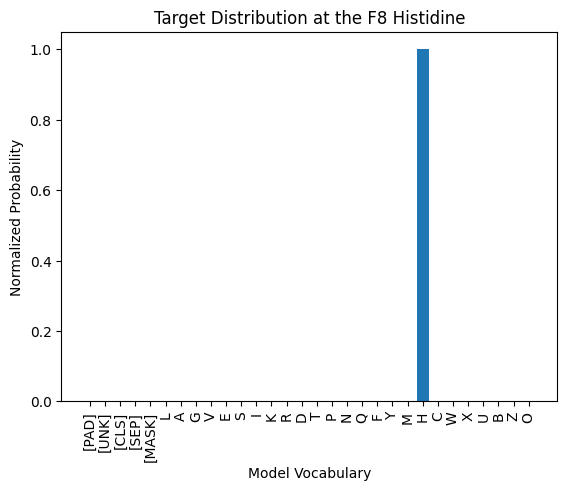

In [ ]:
### 7단계. F8 히스티딘 위치의 토큰 분포를 시각화합니다.
import matplotlib.pyplot as plt

plt.bar(tokenizer.get_vocab().keys(), softmaxed[92])
plt.ylabel('Normalized Probability')
plt.xlabel('Model Vocabulary')
plt.title('Target Distribution at the F8 Histidine')
plt.xticks(rotation='vertical')
plt.show()


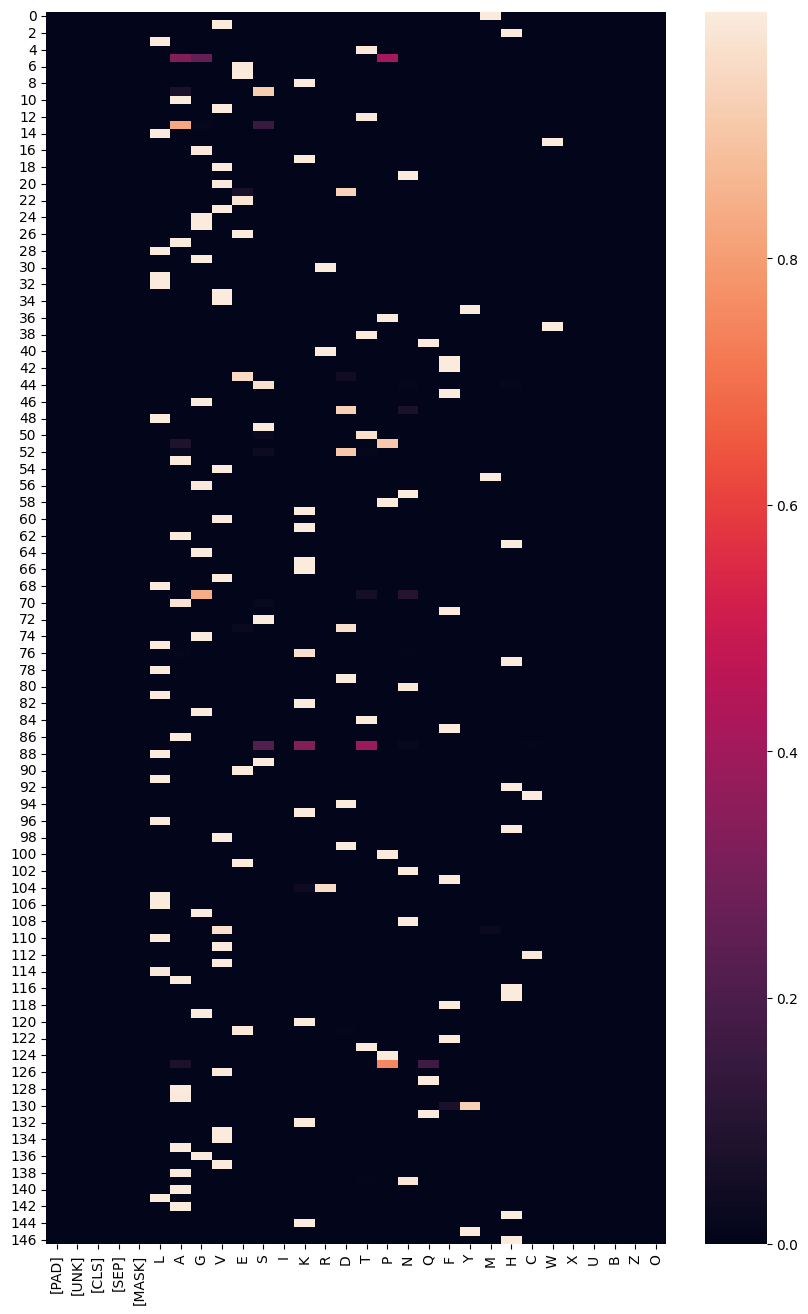

In [ ]:
### [추가] 8단계. 모든 위치에 걸친 로짓 지도를 시각화합니다.
import seaborn as sns

plt.figure(figsize=(10,16))
sns.heatmap(softmaxed, xticklabels=tokenizer.get_vocab())
plt.show()


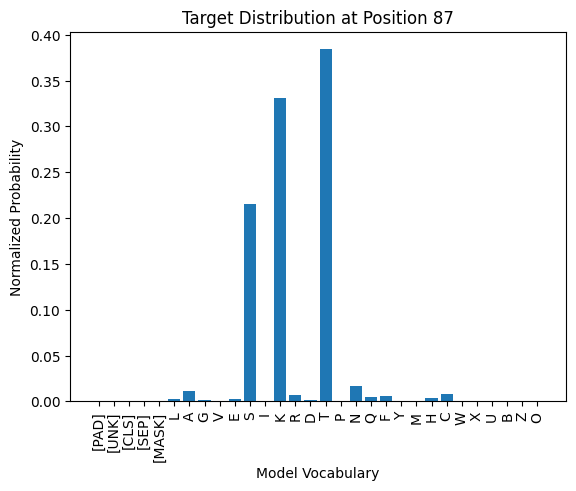

In [ ]:
### [추가] 9단계. 신뢰도가 낮은 영역을 살펴봅니다.

plt.bar(tokenizer.get_vocab().keys(), softmaxed[87])
plt.ylabel('Normalized Probability')
plt.xlabel('Model Vocabulary')
plt.title('Target Distribution at Position 87')
plt.xticks(rotation='vertical')
plt.show()


In [ ]:
for animal in hemoglobin_beta:
    print(f'{animal}의 87번 위치 잔기는 {hemoglobin_beta[animal][87]} 입니다')


human has residue T at position 87
chimpanzee has residue T at position 87
camel has residue K at position 87
rabbit has residue K at position 87
pig has residue K at position 87
horse has residue A at position 87
bovine has residue A at position 87
sheep has residue Q at position 87


위에서 볼 수 있듯, 신뢰도가 낮은 위치에서는 여러 종 사이의 다양성이 커지는 경향이 있습니다. 이는 단백질 세계의 모든 상동 단백질을 사용해 각 아미노산의 확률을 계산했을 때 범주형 분포가 어떻게 보일지에 대한 우리의 이해와 잘 들어맞습니다.


## **7. 맺음말(Concluding Thoughts)**<a name="conclusion"></a>


이 단백질 언어 모델 튜토리얼 0편을 즐기셨길 바랍니다. 이후 튜토리얼에서는 단백질 언어 모델의 구조, 학습된 표현, 그리고 이 놀라운 방법론의 응용을 더 다루겠지만, 세부 내용을 살펴볼 때 이 글이 여러분의 기반이 되길 바랍니다. 이 렌즈로 pLM의 입출력을 분석하면, 특정 예제에서 성능 차이가 나는 이유와 이 모델들이 마주칠 수 있는 실패 양상을 이해하는 데 도움이 됩니다. 빠른 참고를 위해, 이 튜토리얼 범위 안에서의 강점과 한계를 아래에 요약합니다:

### **7.1 강점(Strengths)**

* pLM은 다양한 단백질 패밀리에 걸친 잔기들의 공진화 통계를 학습합니다 [[7]](https://doi.org/10.1101/2024.01.30.577970).
* 단백질 서열만으로 구조와 기능 정보를 포착합니다(서열은 지금까지 가장 풍부하고 정확한 양상입니다).

### **7.2 한계(Limitations)**

* pLM은 고도로 변이된/가변적인 단백질 서열의 분포를 학습하는 데 성능이 떨어집니다. 생식세포계열(germline) 서열로 편향됩니다 [[15]](https://www.biorxiv.org/content/biorxiv/early/2023/09/30/2023.09.28.560044.full.pdf)

* 현재 pLM은 전통적으로 많이 연구된 모델 생물(model organism)에서 유래한 서열로 편향됩니다 [[16]](https://www.biorxiv.org/content/10.1101/2024.03.07.584001v1)


## 이 튜토리얼 인용하기
        
이 튜토리얼이 유용했다면, 아래와 같이 인용해 주시길 부탁드립니다:
```
@manual{Bioinformatics,
title={Protein Language Models (Intuition): A First Look at Modeling Syntax and Semantics of the Known  Protein Universe},
organization={DeepChem},
author={Karthikeyan, Dhuvarakesh and Menezes, Aaron and de Lope, Elisa Gomez},
howpublished = {\\url{https://github.com/deepchem/deepchem/blob/master/examples/tutorials/ProteinLM_Tutorial0.ipynb}},
year={2024},
},
```

## 참고 문헌(References)


[1] Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient Estimation of Word Representations in Vector Space. arXiv [Cs.CL]. Retrieved from http://arxiv.org/abs/1301.3781

[2] Jeffrey Pennington, Richard Socher, and Christopher Manning. 2014. GloVe: Global Vectors for Word Representation. In Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP), pages 1532–1543, Doha, Qatar. Association for Computational Linguistics.

[3] Jacob Devlin, Ming-Wei Chang, Kenton Lee, & Kristina Toutanova. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.

[4] Rao, R., Meier, J., Sercu, T., Ovchinnikov, S., & Rives, A. (2020). Transformer protein language models are unsupervised structure learners. bioRxiv. doi:10.1101/2020.12.15.422761

[5] Ibtehaz, N., Kagaya, Y., & Kihara, D. (2023). Domain-PFP: Protein Function Prediction Using Function-Aware Domain Embedding Representations. bioRxiv. doi:10.1101/2023.08.23.554486

[6] Ahmed Elnaggar, Michael Heinzinger, Christian Dallago, Ghalia Rihawi, Yu Wang, Llion Jones, Tom Gibbs, Tamas Feher, Christoph Angerer, Martin Steinegger, Debsindhu Bhowmik, & Burkhard Rost. (2021). ProtTrans: Towards Cracking the Language of Life's Code Through Self-Supervised Deep Learning and High Performance Computing.

[7] Zhidian Zhang, Hannah K. Wayment-Steele, Garyk Brixi, Haobo Wang, Matteo Dal Peraro, Dorothee Kern, Sergey Ovchinnikov
bioRxiv 2024.01.30.577970; doi: https://doi.org/10.1101/2024.01.30.577970

[8] Zeming Lin, Halil Akin, Roshan Rao, Brian Hie, Zhongkai Zhu, Wenting Lu, Nikita Smetanin, Robert Verkuil, Ori Kabeli, Yaniv Shmueli, Allan dos Santos Costa, Maryam Fazel-Zarandi, Tom Sercu, Salvatore Candido, Alexander Rives
bioRxiv 2022.07.20.500902; doi: https://doi.org/10.1101/2022.07.20.500902

[9] Wang D, Pourmirzaei M, Abbas UL, Zeng S, Manshour N, Esmaili F, Poudel B, Jiang Y, Shao Q, Chen J, Xu D. S-PLM: Structure-aware Protein Language Model via Contrastive Learning between Sequence and Structure. bioRxiv [Preprint]. 2024 May 13:2023.08.06.552203. doi: 10.1101/2023.08.06.552203. PMID: 37609352; PMCID: PMC10441326.

[10] Thomas Hayes, Roshan Rao, Halil Akin, Nicholas J. Sofroniew, Deniz Oktay, Zeming Lin, Robert Verkuil, Vincent Q. Tran, Jonathan Deaton, Marius Wiggert, Rohil Badkundri, Irhum Shafkat, Jun Gong, Alexander Derry, Raul S. Molina, Neil Thomas, Yousuf Khan, Chetan Mishra, Carolyn Kim, Liam J. Bartie, Matthew Nemeth, Patrick D. Hsu, Tom Sercu, Salvatore Candido, Alexander Rives
bioRxiv 2024.07.01.600583; doi: https://doi.org/10.1101/2024.07.01.600583

[11] Roshan M Rao, Jason Liu, Robert Verkuil, Joshua Meier, John Canny, Pieter Abbeel, Tom Sercu, Alexander Rives Proceedings of the 38th International Conference on Machine Learning, PMLR 139:8844-8856, 2021.

[12] Jumper, J., Evans, R., Pritzel, A. et al. Highly accurate protein structure prediction with AlphaFold. Nature 596, 583–589 (2021). https://doi.org/10.1038/s41586-021-03819-2

[13] Ali, A., Baby, B., Soman, S.S. et al. Molecular insights into the interaction of hemorphin and its targets. Sci Rep 9, 14747 (2019). https://doi.org/10.1038/s41598-019-50619-w

[14] Baris E. Suzek, Hongzhan Huang, Peter McGarvey, Raja Mazumder, Cathy H. Wu, UniRef: comprehensive and non-redundant UniProt reference clusters, Bioinformatics, Volume 23, Issue 10, May 2007, Pages 1282–1288, https://doi.org/10.1093/bioinformatics/btm098

[15] Shaw, A., Spinner, H., Shin, J., Gurev, S., Rollins, N., & Marks, D. (2023). Removing bias in sequence models of protein fitness. bioRxiv. doi:10.1101/2023.09.28.560044

[16] Ding, F., & Steinhardt, J. (2024). Protein language models are biased by unequal sequence sampling across the tree of life. doi:10.1101/2024.03.07.584001

### **이 튜토리얼/다른 튜토리얼에 기여하는 방법**

이 튜토리얼에 대한 피드백이 있다면, 이 튜토리얼에 GitHub 이슈를 열어 자유롭게 연락 주세요. 이 튜토리얼 시리즈를 기반으로 발전시키고 싶다면, 다음 두 가지가 자연스럽고 영향력 있는 확장이 될 것입니다:

1. 어텐션 메커니즘과 단백질 언어 모델에서의 그 의의
2. [Zhang 등](https://www.biorxiv.org/content/10.1101/2024.01.30.577970v1.abstract)의 pLM에 대한 범주형 야코비안(Categorical Jacobian) 분석

이 주제에 대한 여러분만의 아이디어도 자유롭게 기여해 주세요.
